PLOT OF AVAILABLE AEROSOL PARTICLES

Aerosol light backscattering coefficient & Aerosol light scattering coefficient (at 450nm, 525nm & 635nm), Equivalent black carbon at 880nm
event and hourly resolution where possible
Aerosol light backscattering coefficient & Aerosol light scattering coefficient (at 450nm, 525nm & 635nm) in 2015 from EBAS: https://ebas-data.nilu.no/Default.aspx - September 2023
All other data from MCH: M:\pay-data\data\pay\Kenya\MKN\incoming\ (\ae33 & \aerosol) 

Author: Sarina Danioth (formerly MeteoSwiss)
Maintainer: joerg.klausen@meteoswiss.ch

[TODO] Needs further clean-up and integration. Not all data sources are currently available from this repo.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib import pyplot
import os
import matplotlib.ticker as ticker
import numpy as np

from datetime import datetime
import itertools

from processing import ebas

In [3]:
#### Aerosol light backscattering coefficient & Aerosol light scattering coefficient (at 450nm, 525nm & 635nm) 2015 from EBAS ####

# read data files and put into data frame
data_path = os.getcwd()+"/data/wdc/ebas/aerosols/KE0001G.20150101000000.20160321124934.nephelometer..aerosol.1y.1h.CH02L_Ecotech_Aurora3000_TLL_dry.CH02L_scat_coef.lev2.nas"
df_aerosol = ebas.ebas_aerosol_file_to_dataframe(data_path=data_path)

,starttime,endtime,aerosol_light_backscattering_coefficient_0,aerosol_light_backscattering_coefficient_1,aerosol_light_backscattering_coefficient_2,aerosol_light_backscattering_coefficient_3,aerosol_light_backscattering_coefficient_4,aerosol_light_backscattering_coefficient_5,aerosol_light_backscattering_coefficient_6,aerosol_light_backscattering_coefficient_7,...,aerosol_light_scattering_coefficient_9,aerosol_light_scattering_coefficient_10,aerosol_light_scattering_coefficient_11,aerosol_light_scattering_coefficient_12,aerosol_light_scattering_coefficient_13,aerosol_light_scattering_coefficient_14,aerosol_light_scattering_coefficient_15,aerosol_light_scattering_coefficient_16,aerosol_light_scattering_coefficient_17,flag
dtm,,,,,,,,,,,,,,,,,,,,,
2015-01-01 00:00:00,0.000000,0.041667,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.999
2015-01-01 01:00:00,0.041667,0.083333,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.999
2015-01-01 02:00:00,0.083333,0.125000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.999
2015-01-01 03:00:00,0.125000,0.166667,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.999
2015-01-01 04:00:00,0.166667,0.208333,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.999
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2015-12-31 19:00:00,364.791667,364.833333,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.456
2015-12-31 20:00:00,364.833333,364.875000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.456
2015-12-31 21:00:00,364.875000,364.916667,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.456


In [4]:
#### Aerosol light backscattering coefficient & Aerosol light scattering coefficient (at 450nm, 525nm & 635nm) after 2015 from MeteoSwiss ####
# data from: M:\pay-data\data\pay\Kenya\MKN\incoming\aerosol\
# wrote all data available until October 05 in /data/aerosol_MCH/ae31_S11/

path = os.getcwd()+ "/data/aerosol_MCH/ae31_S11"

data_ae31_S11 = pd.DataFrame()

for file in os.listdir(path):
    if "ae31_" in str(file):
        data_ae31_S11 = pd.concat([data_ae31_S11, pd.read_csv(path+"/"+file, sep=",", na_values= ["S11a","ZZZ","0","FFFF","FFFF","9999.99"])])

data_ae31_S11['timestamp'] = pd.to_datetime(data_ae31_S11["dtm"]).dt.tz_localize(None)

# hourly aggregates
data_ae31_S11_hourly = pd.DataFrame()
data_ae31_S11_hourly[["BsB_S11","BsG_S11","BsR_S11","BbsB_S11","BbsG_S11","BbsR_S11"]] = data_ae31_S11.groupby(data_ae31_S11['timestamp'].dt.strftime("%y-%m-%d %H"))[["BsB_S11","BsG_S11","BsR_S11","BbsB_S11","BbsG_S11","BbsR_S11"]].mean()
data_ae31_S11_hourly.index.name = 'timestamp'
data_ae31_S11_hourly.reset_index(inplace=True)
data_ae31_S11_hourly['timestamp'] = pd.to_datetime(data_ae31_S11_hourly['timestamp'], format="%y-%m-%d %H")


In [5]:
#### Black carbon (from ae31) at 880nm ####
# data from: M:\pay-data\data\pay\Kenya\MKN\incoming\aerosol\
# wrote all data available until October 05 in /data/aerosol_MCH/ae31/ae31_A11.txt

# read data
data_path = os.getcwd() + "/data/aerosol_MCH/ae31/ae31_A11.txt"
data_ae31_all = pd.read_csv(data_path, sep=",")
data_ae31_all['timestamp'] = pd.to_datetime(data_ae31_all["dtm"]).dt.tz_localize(None)

# create hourly aggregates
data_ae31_all_hourly = pd.DataFrame()
data_ae31_all_hourly[['X1c_A11', 'X2c_A11', 'X3c_A11', 'X4c_A11', 'X5c_A11', 'X6c_A11', 'X7c_A11']] = data_ae31_all.groupby(data_ae31_all['timestamp'].dt.strftime("%y-%m-%d %H"))[['X1c_A11', 'X2c_A11', 'X3c_A11', 'X4c_A11', 'X5c_A11', 'X6c_A11', 'X7c_A11']].mean()
data_ae31_all_hourly.index.name = 'timestamp'
data_ae31_all_hourly.reset_index(inplace=True)
data_ae31_all_hourly['timestamp'] = pd.to_datetime(data_ae31_all_hourly['timestamp'], format="%y-%m-%d %H")


In [6]:
#### Black carbon (from ae33) at 880nm ####
# data from: M:\pay-data\data\pay\Kenya\MKN\incoming\ae33\
# wrote all data available until October 05 in files /data/aerosol_MCH/ae33/

path = os.getcwd()+"/data/aerosol_MCH/ae33"

data_ae33_all = pd.DataFrame()

for file in os.listdir(path):
    if "ae33_" in str(file):
        data_ae33_all = pd.concat([data_ae33_all, pd.read_csv(path+"/"+file, sep=",")])

# create hourly aggregates
data_ae33_all['timestamp'] = pd.to_datetime(data_ae33_all["dtm"]).dt.tz_localize(None)
data_ae33_all_hourly = pd.DataFrame()
data_ae33_all_hourly['BC6'] = data_ae33_all.groupby(data_ae33_all['timestamp'].dt.strftime("%y-%m-%d %H"))[['BC6']].mean()
data_ae33_all_hourly.index.name = 'timestamp'
data_ae33_all_hourly.reset_index(inplace=True)
data_ae33_all_hourly['timestamp'] = pd.to_datetime(data_ae33_all_hourly['timestamp'], format="%y-%m-%d %H")

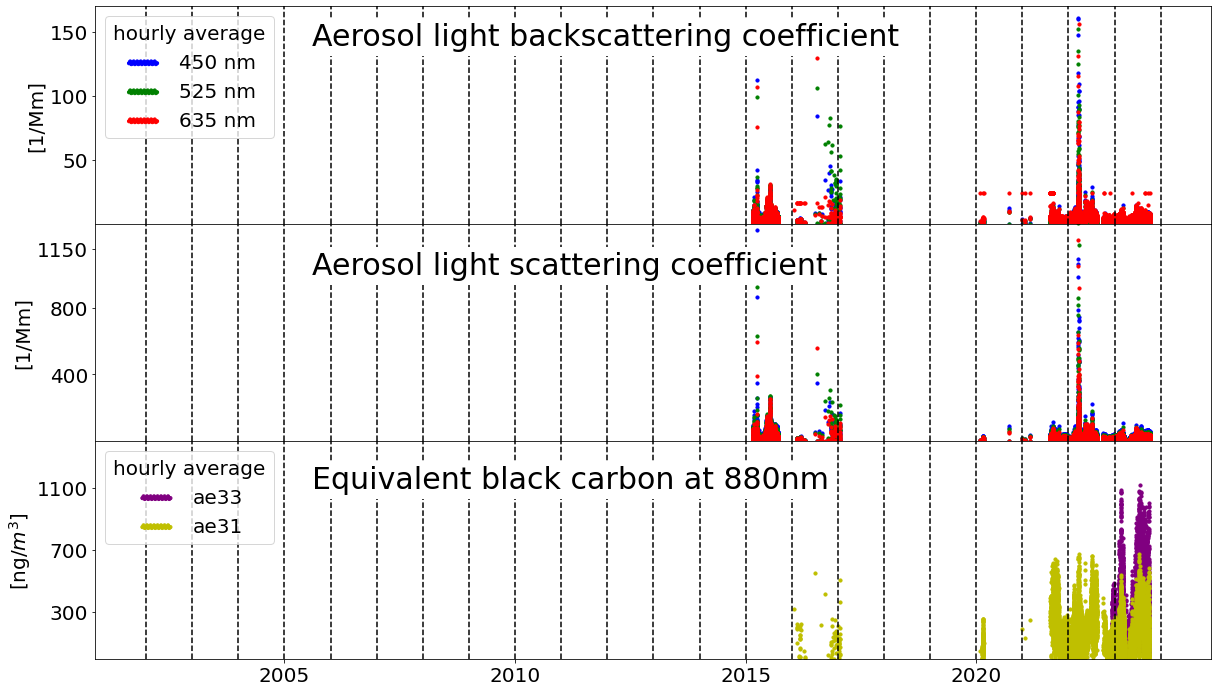

In [7]:
# Make Plot

fig = plt.figure(figsize=(20,12))
plt.subplots_adjust(hspace=0)
ax1 = plt.subplot(311)
ax2 = plt.subplot(312)
ax3 = plt.subplot(313)

# xlabel
x_dates = []
for y in range(2002,2025):
    x_dates.append(str(y)+"-01-01")

#### Aerosol light backscattering ####
ax1.scatter(df_aerosol["dtm"],df_aerosol["aerosol_light_backscattering_coefficient_0"], marker="o", s= 10, c= "blue") #EBAS-2015
ax1.scatter(df_aerosol["dtm"],df_aerosol["aerosol_light_backscattering_coefficient_3"], marker="o", s= 10, c="green") #EBAS-2015
ax1.scatter(df_aerosol["dtm"],df_aerosol["aerosol_light_backscattering_coefficient_6"], marker="o", s= 10, c="red") #EBAS-2015
ax1.scatter(data_ae31_S11_hourly["timestamp"],data_ae31_S11_hourly["BbsB_S11"], marker="o", s= 10, label="450 nm", c= "blue") #MeteoSwiss
ax1.scatter(data_ae31_S11_hourly["timestamp"],data_ae31_S11_hourly["BbsG_S11"], marker="o", s= 10, label="525 nm", c= "green") #MeteoSwiss
ax1.scatter(data_ae31_S11_hourly["timestamp"],data_ae31_S11_hourly["BbsR_S11"], marker="o", s= 10, label="635 nm", c= "red") #MeteoSwiss
ax1.set_ylim(0,170)
ax1.set_ylabel("[1/Mm]", fontsize=20)
ax1.vlines(x = x_dates, ymin=0, ymax=200, colors="k", ls="--")
ax1.set_yticks([50,100, 150])
ax1.legend(loc="upper left", fontsize=20, scatterpoints=25, title="hourly average", title_fontsize=20)
t = ax1.text(13000, 140, "Aerosol light backscattering coefficient", fontsize=30)
t.set_bbox(dict(facecolor='white', alpha=1, edgecolor='white'))
ax1.tick_params(axis="y", labelsize=20)


#### Aerosol light scattering ####
ax2.scatter(df_aerosol["dtm"],df_aerosol["aerosol_light_scattering_coefficient_9"], marker="o", s= 10,  c= "blue") #EBAS-2015
ax2.scatter(df_aerosol["dtm"],df_aerosol["aerosol_light_scattering_coefficient_12"], marker="o", s= 10, c="green") #EBAS-2015
ax2.scatter(df_aerosol["dtm"],df_aerosol["aerosol_light_scattering_coefficient_15"], marker="o", s= 10, c="red") #EBAS-2015
ax2.scatter(data_ae31_S11_hourly["timestamp"],data_ae31_S11_hourly["BsB_S11"], marker="o", s= 10, label="450 nm", c= "blue") #MeteoSwiss ae31
ax2.scatter(data_ae31_S11_hourly["timestamp"],data_ae31_S11_hourly["BsG_S11"], marker="o", s= 10, label="525 nm", c= "green") #MeteoSwiss ae31
ax2.scatter(data_ae31_S11_hourly["timestamp"],data_ae31_S11_hourly["BsR_S11"], marker="o", s= 10, label="635 nm", c= "red") #MeteoSwiss ae31
ax2.set_ylim(0,1300)
ax2.set_ylabel("[1/Mm]", fontsize=20)
ax2.vlines(x = x_dates, ymin=0, ymax=1500, colors="k", ls="--")
ax2.set_yticks([400,800, 1150])
t = ax2.text(13000, 1000, "Aerosol light scattering coefficient", fontsize=30)
t.set_bbox(dict(facecolor='white', alpha=1, edgecolor='white'))
ax2.tick_params(axis="y", labelsize=20)


#### Black carbon (ng/m3) ####
ax3.scatter(data_ae33_all_hourly['timestamp'], data_ae33_all_hourly["BC6"], marker="o", s= 10, label="ae33", c="purple") #MeteoSwiss ae33
ax3.scatter(data_ae31_all_hourly['timestamp'],data_ae31_all_hourly["X6c_A11"], marker="o", s= 10, label="ae31", c="y") #MeteoSwiss ae31
ax3.set_ylim(0,1400)
ax3.set_ylabel("[ng/$m^3$]", fontsize=20)
ax3.vlines(x = x_dates, ymin=0, ymax=2000, colors="k", ls="--")
ax3.set_yticks([300,700,1100])
ax3.legend(loc="upper left", title="hourly average", fontsize=20, scatterpoints=25, title_fontsize=20)
t = ax3.text(13000, 1100, "Equivalent black carbon at 880nm", fontsize=30)
t.set_bbox(dict(facecolor='white', alpha=1, edgecolor='white'))
ax3.tick_params(axis="x", labelsize=20)
ax3.set_xticks(["2005","2010", "2015", "2020"], ["2005","2010", "2015", "2020"])
ax3.tick_params(axis="y", labelsize=20)

# save figure
#fig.savefig(os.getcwd()+"/data/plots/Aerosol_Particles.jpeg", bbox_inches='tight')